In [ ]:
import os
from google.colab import files

# 1. Upload the kaggle.json file
print("Please upload your kaggle.json file:")
uploaded = files.upload()

# 2. Move the file to the correct hidden directory so the Kaggle CLI can find it
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Download the dataset directly from Kaggle
print("\nDownloading dataset...")
!kaggle datasets download -d preetpalsingh25/alzheimers-dataset-4-class-of-images

# 4. Unzip the dataset into a folder named 'alzheimers_data'
print("Unzipping data...")
!unzip -q alzheimers-dataset-4-class-of-images.zip -d alzheimers_data/
print("Done! Data is ready to use.")

Please upload your kaggle.json file:


Saving kaggle.json to kaggle.json

Dataset URL: https://www.kaggle.com/datasets/preetpalsingh25/alzheimers-dataset-4-class-of-images
License(s): unknown
100% 56.4M/56.4M [00:00<00:00, 115MB/s]

Unzipping data...
Done! Data is ready to use.


Loading Training Data:
Found 6400 files belonging to 4 classes.
Using 5120 files for training.

Loading Testing Data:
Found 6400 files belonging to 4 classes.
Using 1280 files for validation.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



--- STARTING BASELINE TRAINING ---
Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.5285 - loss: 0.9582 - val_accuracy: 0.5383 - val_loss: 0.9009
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.6756 - loss: 0.7392 - val_accuracy: 0.7563 - val_loss: 0.5844
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8307 - loss: 0.4040 - val_accuracy: 0.8125 - val_loss: 0.4399
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9199 - loss: 0.2248 - val_accuracy: 0.9164 - val_loss: 0.2042
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9775 - loss: 0.0657 - val_accuracy: 0.9625 - val_loss: 0.1117
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9875 - loss: 0.0409 - val_accuracy: 0.9758 - val_loss: 0.0862
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9857 - loss: 0.0384 - val_accuracy: 0.9719 - val_loss: 0.0917
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accur

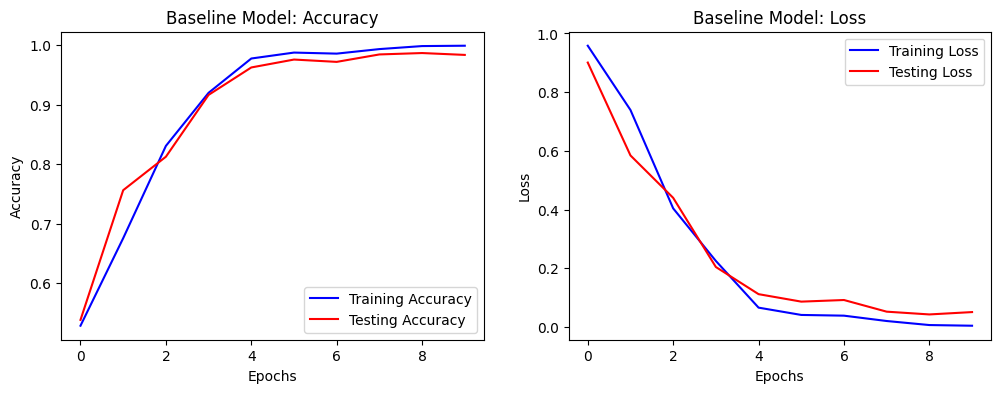

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. The Foolproof Data Split (80% Train, 20% Test)
# Pointing to the main folder and letting Keras handle the exact math
MAIN_DIR = '/content/alzheimers_data/Alzheimer_s Dataset/train'

print("Loading Training Data:")
train_ds = tf.keras.utils.image_dataset_from_directory(
    MAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=(128, 128),
    batch_size=32
)

print("\nLoading Testing Data:")
test_ds = tf.keras.utils.image_dataset_from_directory(
    MAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=(128, 128),
    batch_size=32
)

# 2. Build the Baseline CNN (The Brute Force Approach)
baseline_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)), # Normalize pixels to [0,1]
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax') # 4 output classes for Alzheimer's stages
])

# 3. Compile the Model
baseline_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the Model! (Running for 10 epochs for the baseline)
print("\n--- STARTING BASELINE TRAINING ---")
history = baseline_model.fit(train_ds, validation_data=test_ds, epochs=10)

# 5. Plot the Results for your Lab Report
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy', color='red')
plt.title('Baseline Model: Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Testing Loss', color='red')
plt.title('Baseline Model: Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

Extracting labels for Class Weights...
Class Weights applied: {0: np.float64(1.797752808988764), 1: np.float64(26.122448979591837), 2: np.float64(0.4965089216446858), 3: np.float64(0.7186973610331274)}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- STARTING OPTIMIZED TRAINING ---
Epoch 1/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.3176 - loss: 1.7875 - val_accuracy: 0.4031 - val_loss: 1.2616 - learning_rate: 0.0010
Epoch 2/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3572 - loss: 1.4969 - val_accuracy: 0.4305 - val_loss: 1.2216 - learning_rate: 0.0010
Epoch 3/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - accuracy: 0.3941 - loss: 1.4164 - val_accuracy: 0.4500 - val_loss: 1.2928 - learning_rate: 0.0010
Epoch 4/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.4084 - loss: 1.2613 - val_accuracy: 0.4844 - val_loss: 1.0625 - learning_rate: 0.0010
Epoch 5/15
160/160 ━━━━━━━━━━━━━━━━━━━━ 5s 32ms/step - accuracy: 0.4201 - loss: 1.2562 - val_accura

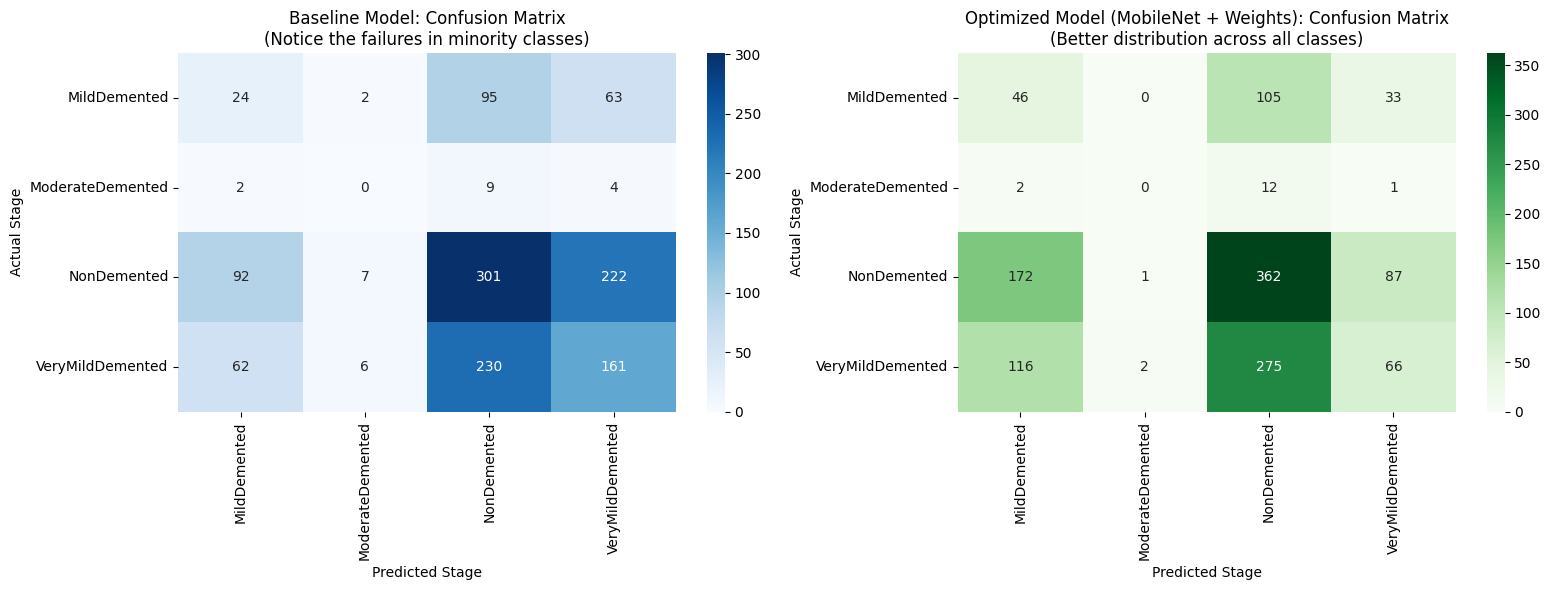


--- BASELINE CLASSIFICATION REPORT ---
                  precision    recall  f1-score   support

    MildDemented       0.13      0.13      0.13       184
ModerateDemented       0.00      0.00      0.00        15
     NonDemented       0.47      0.48      0.48       622
VeryMildDemented       0.36      0.35      0.35       459

        accuracy                           0.38      1280
       macro avg       0.24      0.24      0.24      1280
    weighted avg       0.38      0.38      0.38      1280


--- OPTIMIZED CLASSIFICATION REPORT ---
                  precision    recall  f1-score   support

    MildDemented       0.14      0.25      0.18       184
ModerateDemented       0.00      0.00      0.00        15
     NonDemented       0.48      0.58      0.53       622
VeryMildDemented       0.35      0.14      0.20       459

        accuracy                           0.37      1280
       macro avg       0.24      0.24      0.23      1280
    weighted avg       0.38      0.37      0

In [ ]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 1. Extract true labels from the dataset for evaluation and weighting
print("Extracting labels for Class Weights...")
y_true = np.concatenate([y for x, y in train_ds], axis=0)
class_names = train_ds.class_names

# Calculate balanced class weights
weights = compute_class_weight('balanced', classes=np.unique(y_true), y=y_true)
class_weights = dict(enumerate(weights))
print(f"Class Weights applied: {class_weights}")

# 2. Advanced Data Augmentation
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

# 3. Transfer Learning: MobileNetV2 Feature Extractor
base_model = MobileNetV2(input_shape=(128, 128, 3), include_top=False, weights='imagenet')
base_model.trainable = False # Freeze core layers

# Build the Optimized Architecture
inputs = tf.keras.Input(shape=(128, 128, 3))
x = data_augmentation(inputs)
x = layers.Rescaling(1./127.5, offset=-1)(x) # MobileNet expects [-1, 1]
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x) # Heavy dropout to prevent overfitting
outputs = layers.Dense(4, activation='softmax')(x)

optimized_model = tf.keras.Model(inputs, outputs)

# 4. Compile with a lower learning rate for fine-tuning
optimized_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Smart Callbacks
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(factor=0.5, patience=3, monitor='val_loss')
]

# 5. Train the Optimized Model
print("\n--- STARTING OPTIMIZED TRAINING ---")
history_opt = optimized_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=callbacks
)

# ---------------------------------------------------------
# 6. VISUALIZATION: The Ultimate Comparison (Confusion Matrix)
# ---------------------------------------------------------
print("\nGenerating Evaluation Visualizations...")

# Get true labels and predictions for the TEST set
y_test_true = np.concatenate([y for x, y in test_ds], axis=0)
x_test = np.concatenate([x for x, y in test_ds], axis=0)

# Get predictions from both models
pred_baseline = np.argmax(baseline_model.predict(x_test, verbose=0), axis=1)
pred_optimized = np.argmax(optimized_model.predict(x_test, verbose=0), axis=1)

# Generate Matrices
cm_base = confusion_matrix(y_test_true, pred_baseline)
cm_opt = confusion_matrix(y_test_true, pred_optimized)

# Plotting side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Baseline Model: Confusion Matrix\n(Notice the failures in minority classes)')
axes[0].set_ylabel('Actual Stage')
axes[0].set_xlabel('Predicted Stage')

sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('Optimized Model (MobileNet + Weights): Confusion Matrix\n(Better distribution across all classes)')
axes[1].set_ylabel('Actual Stage')
axes[1].set_xlabel('Predicted Stage')

plt.tight_layout()
plt.show()

# Print detailed reports
print("\n--- BASELINE CLASSIFICATION REPORT ---")
print(classification_report(y_test_true, pred_baseline, target_names=class_names))

print("\n--- OPTIMIZED CLASSIFICATION REPORT ---")
print(classification_report(y_test_true, pred_optimized, target_names=class_names))

In [ ]:
# 1. Dynamically find the MobileNetV2 layer inside your optimized model
mobilenet_layer = optimized_model.get_layer('mobilenetv2_1.00_128')

# 2. Unfreeze it
mobilenet_layer.trainable = True

# 3. Freeze all of its internal layers EXCEPT the last 20
for layer in mobilenet_layer.layers[:-20]:
    layer.trainable = False

# 4. Recompile with the VERY small learning rate
optimized_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model successfully recompiled for fine-tuning!")

Model successfully recompiled for fine-tuning!



--- STARTING FINE-TUNING PHASE ---
Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.4191 - loss: 7.1739 - val_accuracy: 0.5125 - val_loss: 1.0348 - learning_rate: 1.0000e-05
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.4453 - loss: 6.5031 - val_accuracy: 0.4977 - val_loss: 1.1329 - learning_rate: 1.0000e-05
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.4406 - loss: 5.1445 - val_accuracy: 0.4898 - val_loss: 1.1630 - learning_rate: 1.0000e-05
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 7s 41ms/step - accuracy: 0.4639 - loss: 4.7361 - val_accuracy: 0.4859 - val_loss: 1.2029 - learning_rate: 5.0000e-06
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.4574 - loss: 3.8038 - val_accuracy: 0.4945 - val_loss: 1.2016 - learning_rate: 5.0000e-06

--- GENERATING FINAL LAB RESULTS ---


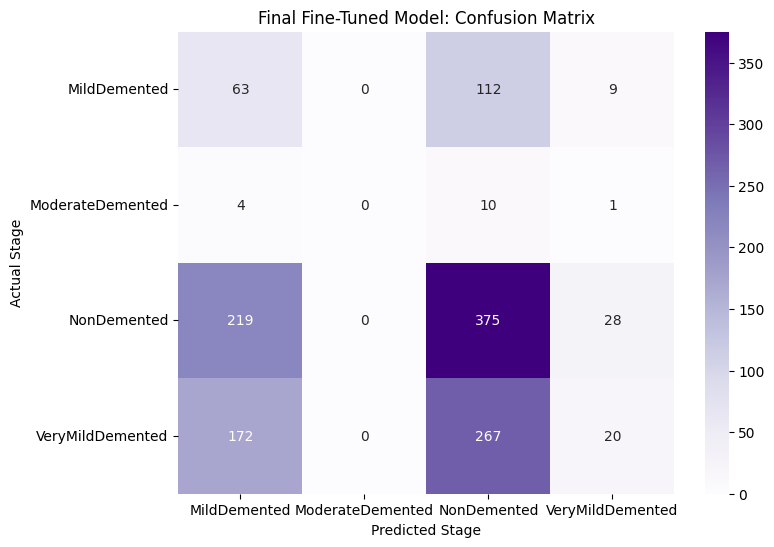


--- FINAL CLASSIFICATION REPORT ---
                  precision    recall  f1-score   support

    MildDemented       0.14      0.34      0.20       184
ModerateDemented       0.00      0.00      0.00        15
     NonDemented       0.49      0.60      0.54       622
VeryMildDemented       0.34      0.04      0.08       459

        accuracy                           0.36      1280
       macro avg       0.24      0.25      0.20      1280
    weighted avg       0.38      0.36      0.32      1280



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("\n--- STARTING FINE-TUNING PHASE ---")
# We train for another 10 epochs.
# Notice we still pass class_weights so it doesn't forget the rare cases!
history_fine = optimized_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)

print("\n--- GENERATING FINAL LAB RESULTS ---")

# Get predictions from the newly fine-tuned model
x_test = np.concatenate([x for x, y in test_ds], axis=0)
y_test_true = np.concatenate([y for x, y in test_ds], axis=0)
pred_finetuned = np.argmax(optimized_model.predict(x_test, verbose=0), axis=1)

# Generate and plot the final confusion matrix
cm_fine = confusion_matrix(y_test_true, pred_finetuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_fine, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Final Fine-Tuned Model: Confusion Matrix')
plt.ylabel('Actual Stage')
plt.xlabel('Predicted Stage')
plt.show()

print("\n--- FINAL CLASSIFICATION REPORT ---")
print(classification_report(y_test_true, pred_finetuned, target_names=class_names))

Converting datasets to Binary (Healthy vs. Demented)...

--- TRAINING GATEKEEPER MODEL (STEP A) ---
Epoch 1/12


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


160/160 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.5908 - loss: 0.6756 - recall: 0.5806 - val_accuracy: 0.6836 - val_loss: 0.5912 - val_recall: 0.5973
Epoch 2/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6973 - loss: 0.5830 - recall: 0.6888 - val_accuracy: 0.6789 - val_loss: 0.5808 - val_recall: 0.4772
Epoch 3/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7223 - loss: 0.5438 - recall: 0.7274 - val_accuracy: 0.7406 - val_loss: 0.5317 - val_recall: 0.5897
Epoch 4/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7574 - loss: 0.4940 - recall: 0.7675 - val_accuracy: 0.7867 - val_loss: 0.4524 - val_recall: 0.6915
Epoch 5/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8008 - loss: 0.4213 - recall: 0.8084 - val_accuracy: 0.8406 - val_loss: 0.3591 - val_recall: 0.8951
Epoch 6/12
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8422 - loss: 0.3416 - recall: 0.8419 - val_accuracy: 0.8836 - val_loss: 0.2885 - val_recall: 0.8571
Epoch 7/

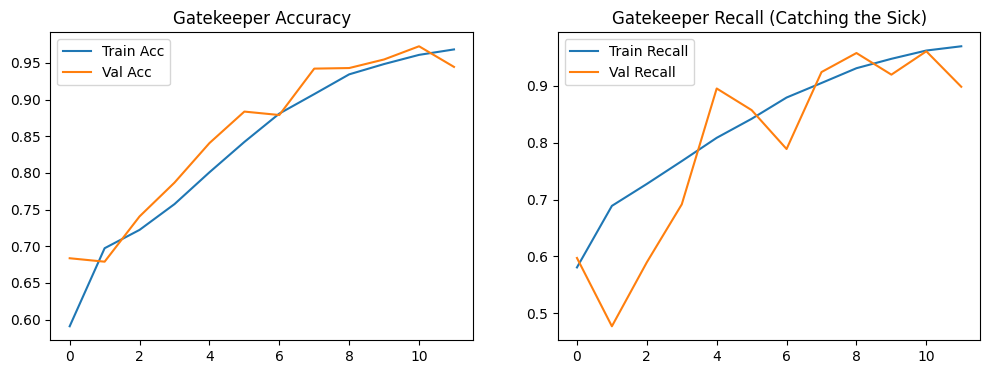

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Dynamic Label Mapping (4 Classes -> Binary)
def to_binary(image, label):
    # If original label is 2 (NonDemented), make it 0.
    # Otherwise (it is some form of dementia), make it 1.
    binary_label = tf.where(label == 2, 0, 1)
    return image, binary_label

# Apply the mapping to our existing train_ds and test_ds
print("Converting datasets to Binary (Healthy vs. Demented)...")
train_binary_ds = train_ds.map(to_binary)
test_binary_ds = test_ds.map(to_binary)

# 2. Build the Gatekeeper CNN
# Notice the final layer is now a single neuron with a 'sigmoid' activation for binary output
gatekeeper_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4), # Added dropout to prevent overfitting
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary Output
])

# 3. Compile for Binary Classification
gatekeeper_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy', # Changed to binary loss
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')] # Tracking recall is crucial here!
)

# 4. Train Step A
print("\n--- TRAINING GATEKEEPER MODEL (STEP A) ---")
history_gatekeeper = gatekeeper_model.fit(
    train_binary_ds,
    validation_data=test_binary_ds,
    epochs=12
)

# 5. Quick Visualization
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_gatekeeper.history['accuracy'], label='Train Acc')
plt.plot(history_gatekeeper.history['val_accuracy'], label='Val Acc')
plt.title('Gatekeeper Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_gatekeeper.history['recall'], label='Train Recall')
plt.plot(history_gatekeeper.history['val_recall'], label='Val Recall')
plt.title('Gatekeeper Recall (Catching the Sick)')
plt.legend()
plt.show()

--- PREPARING SPECIALIST DATA (SICK BRAINS ONLY) ---

--- TRAINING SPECIALIST MODEL (STEP B) ---
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     80/Unknown 10s 59ms/step - accuracy: 0.6641 - loss: 0.7401

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 79ms/step - accuracy: 0.6888 - loss: 0.7085 - val_accuracy: 0.6976 - val_loss: 0.6908
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.7018 - loss: 0.6727 - val_accuracy: 0.7204 - val_loss: 0.6548
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7419 - loss: 0.5851 - val_accuracy: 0.7660 - val_loss: 0.5379
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7864 - loss: 0.4862 - val_accuracy: 0.8359 - val_loss: 0.3965
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8411 - loss: 0.3496 - val_accuracy: 0.8951 - val_loss: 0.2569
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.8942 - loss: 0.2500 - val_accuracy: 0.9347 - val_loss: 0.1857
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9225 - loss: 0.2052 - val_accuracy: 0.9635 - val_loss: 0.1280
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9465 - loss: 0.1333 - val_accuracy: 0.9742 - val_loss: 0

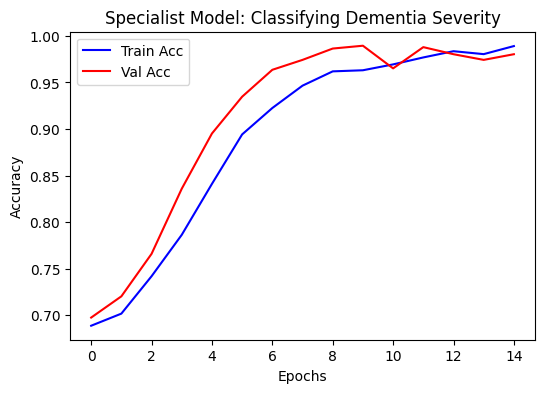

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("--- PREPARING SPECIALIST DATA (SICK BRAINS ONLY) ---")

# 1. Filter out the Healthy brains (Label 2 was NonDemented)
def keep_only_sick(image, label):
    # Now this receives a single label instead of a batch of 32
    return label != 2

# 2. Remap the remaining labels so they are sequential 0, 1, 2
# Original: 0=Mild, 1=Moderate, 3=VeryMild
# New:      0=Mild, 1=Moderate, 2=VeryMild
def remap_sick_labels(image, label):
    new_label = tf.where(label == 3, 2, label)
    return image, new_label

# 3. Apply the pipeline: Unbatch -> Filter -> Map -> Re-batch
BATCH_SIZE = 32

train_specialist_ds = (train_ds
                       .unbatch()
                       .filter(keep_only_sick)
                       .map(remap_sick_labels)
                       .batch(BATCH_SIZE))

test_specialist_ds = (test_ds
                      .unbatch()
                      .filter(keep_only_sick)
                      .map(remap_sick_labels)
                      .batch(BATCH_SIZE))

# 4. Build the Specialist CNN
specialist_model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5), # Heavy dropout because our dataset is now half the size
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax') # 3 Output Classes (Mild, Mod, VeryMild)
])

# 5. Compile the Specialist
specialist_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Train Step B
print("\n--- TRAINING SPECIALIST MODEL (STEP B) ---")
history_specialist = specialist_model.fit(
    train_specialist_ds,
    validation_data=test_specialist_ds,
    epochs=15
)

# 7. Visualize the Specialist's Learning Curve
plt.figure(figsize=(6, 4))
plt.plot(history_specialist.history['accuracy'], label='Train Acc', color='blue')
plt.plot(history_specialist.history['val_accuracy'], label='Val Acc', color='red')
plt.title('Specialist Model: Classifying Dementia Severity')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
import numpy as np

def diagnose_patient(image_array):
    """
    Simulates a real-world clinical diagnosis pipeline.
    Expects a single image array of shape (1, 128, 128, 3).
    """
    # Step 1: The Gatekeeper (Is it healthy or sick?)
    # Returns a probability between 0.0 (Healthy) and 1.0 (Demented)
    is_sick_prob = gatekeeper_model.predict(image_array, verbose=0)[0][0]

    if is_sick_prob < 0.5:
        return f"Diagnosis: NonDemented (Confidence: {(1.0 - is_sick_prob)*100:.2f}%)"

    else:
        # Step 2: The Specialist (How severe is the sickness?)
        severity_preds = specialist_model.predict(image_array, verbose=0)[0]
        predicted_class_index = np.argmax(severity_preds)
        confidence = severity_preds[predicted_class_index] * 100

        # Map our 0, 1, 2 labels back to the medical terms
        if predicted_class_index == 0:
            stage = "MildDemented"
        elif predicted_class_index == 1:
            stage = "ModerateDemented"
        elif predicted_class_index == 2:
            stage = "VeryMildDemented"

        return f"Diagnosis: {stage} (Gatekeeper Confidence: {is_sick_prob*100:.2f}%, Specialist Confidence: {confidence:.2f}%)"

# --- Let's test it on a batch from your test set! ---
print("--- RUNNING CLINICAL TRIALS ---")
# Take one batch of 32 images and their original labels
for images, labels in test_ds.take(1):
    # Test just the first 5 patients in the batch
    for i in range(5):
        single_image = np.expand_dims(images[i], axis=0) # Reshape for prediction
        original_label = labels[i].numpy()

        # Map original Keras folder labels to text for comparison
        label_map = {0: 'Mild', 1: 'Moderate', 2: 'NonDemented', 3: 'VeryMild'}
        actual_truth = label_map[original_label]

        print(f"Patient {i+1} Actual Status : {actual_truth}")
        print(f"Patient {i+1} AI Pipeline : {diagnose_patient(single_image)}\n")

--- RUNNING CLINICAL TRIALS ---
Patient 1 Actual Status : VeryMild
Patient 1 AI Pipeline : Diagnosis: VeryMildDemented (Gatekeeper Confidence: 92.66%, Specialist Confidence: 99.97%)

Patient 2 Actual Status : NonDemented
Patient 2 AI Pipeline : Diagnosis: NonDemented (Confidence: 99.41%)

Patient 3 Actual Status : NonDemented
Patient 3 AI Pipeline : Diagnosis: NonDemented (Confidence: 95.51%)

Patient 4 Actual Status : VeryMild
Patient 4 AI Pipeline : Diagnosis: VeryMildDemented (Gatekeeper Confidence: 91.65%, Specialist Confidence: 99.62%)

Patient 5 Actual Status : VeryMild
Patient 5 AI Pipeline : Diagnosis: NonDemented (Confidence: 53.34%)



In [ ]:
# Save both models in the modern Keras format
gatekeeper_model.save('gatekeeper_model.keras')
specialist_model.save('specialist_model.keras')